# Линейная регрессия на практике

Рассмотрим набор данных, содержащий информацию о привычках студентов и их успеваемости.

Задача состоит в составлении регрессионной модели для предсказания оценки на экзамене по образу жизни студента.

In [1]:
# ! unzip ./student_habits_performance.zip -d ./

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RANSACRegressor

In [3]:
df = pd.read_csv("./student_habits_performance.csv")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Выведем основную информацию о данных.

## Распределение данных

Рассмотрение набора данных полезно начинать с изучения распределения данных.

Размер набора данных: 1000
Распределение данных:


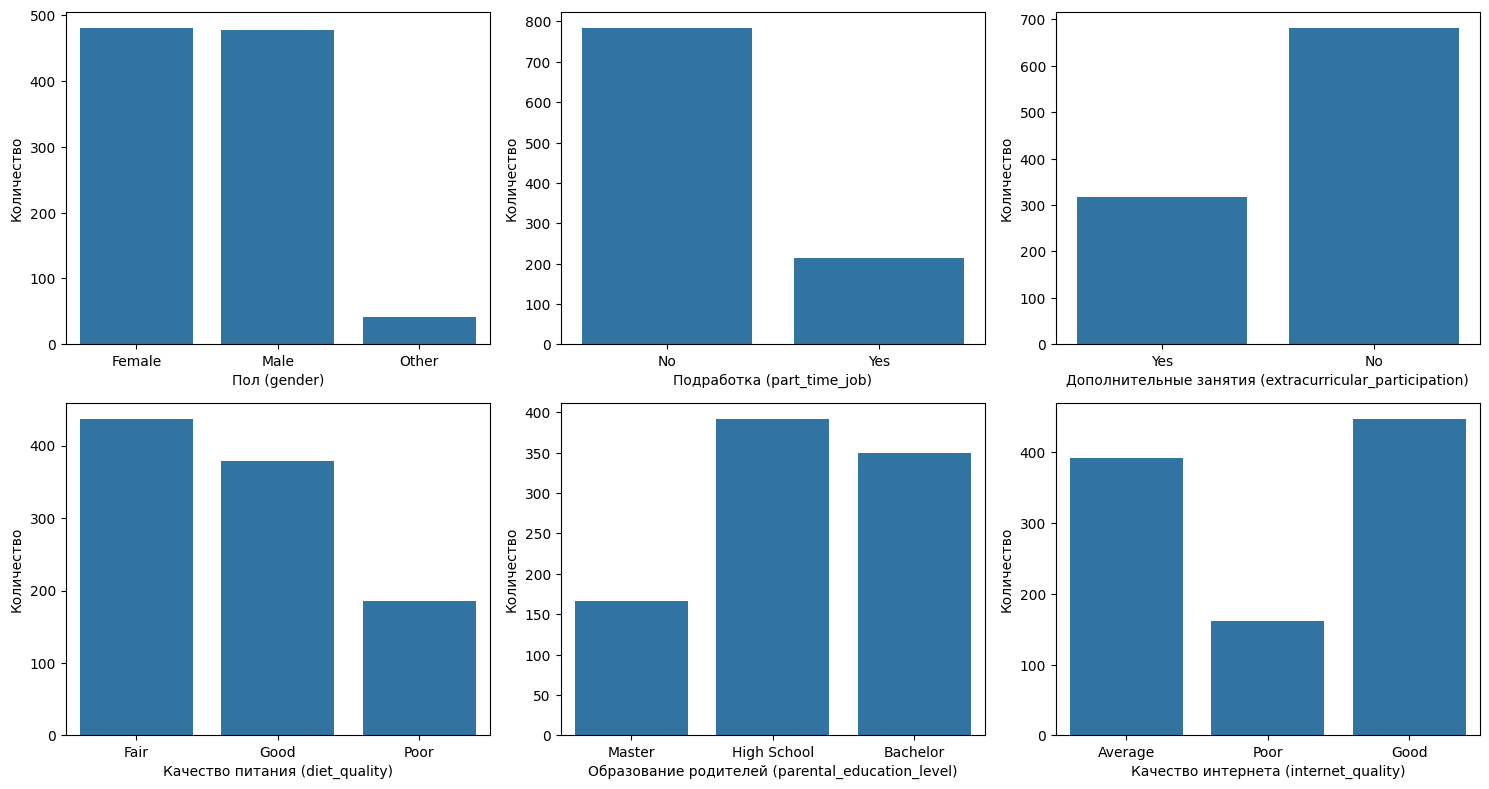

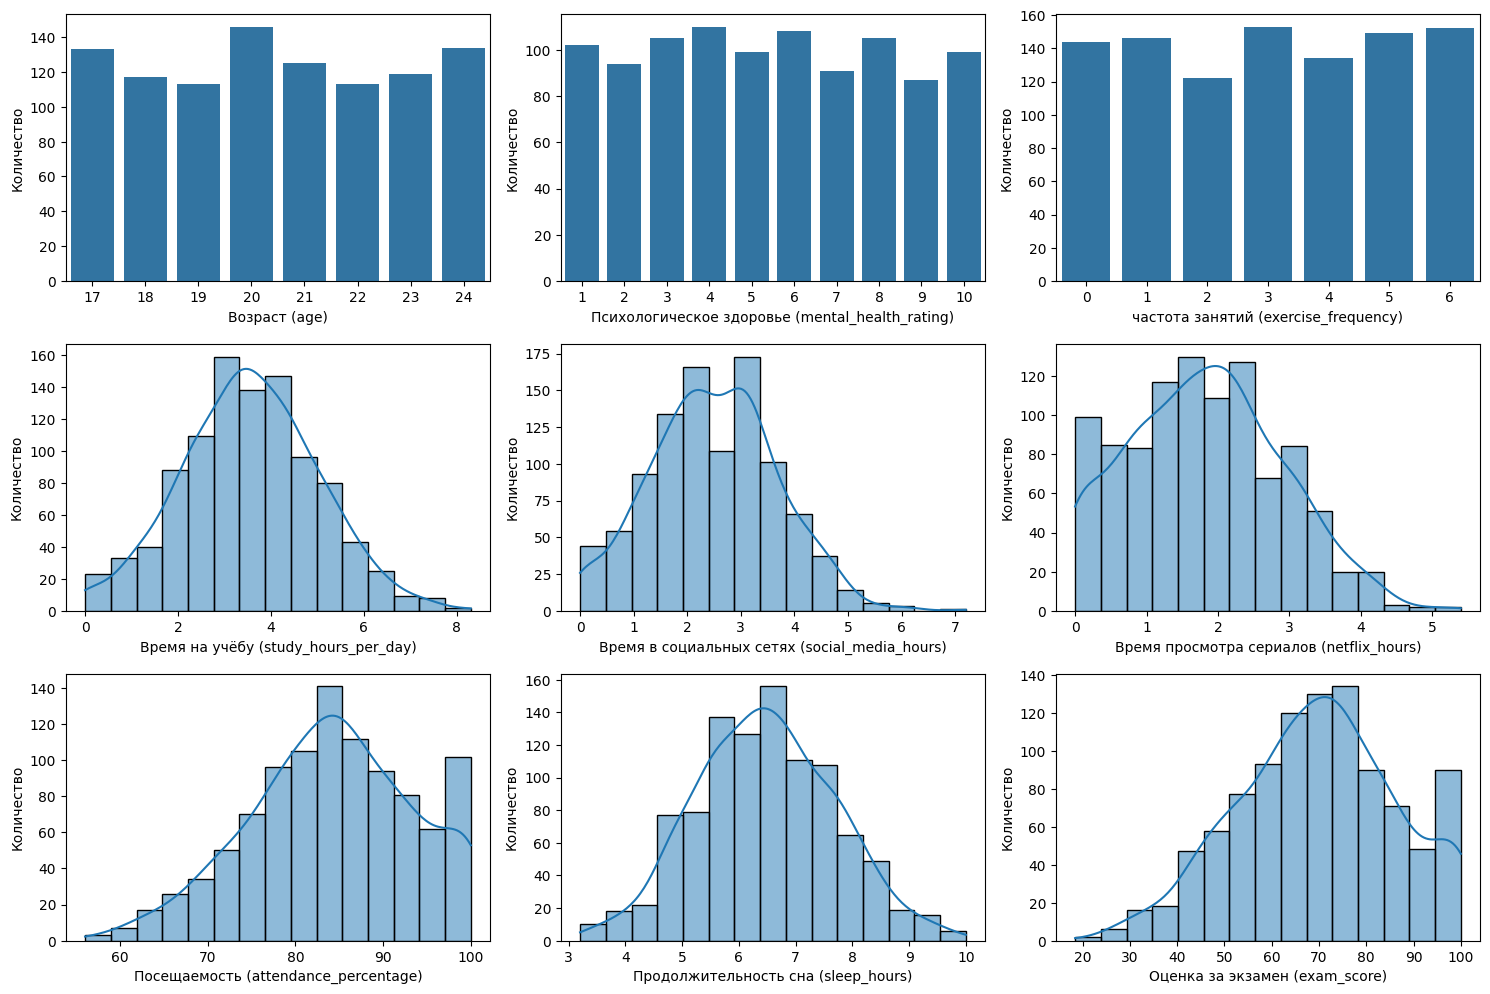

In [4]:
print(f"Размер набора данных: {len(df)}")

print(f"Распределение данных:")

categorical_columns = [ 
    ("gender", "Пол"),
    ("part_time_job", "Подработка"),
    ("extracurricular_participation", "Дополнительные занятия"),
    ("diet_quality", "Качество питания"),    
    ("parental_education_level", "Образование родителей"),
    ("internet_quality", "Качество интернета"),
]

numerical_columns = [
    ("age", "Возраст"),
    ("mental_health_rating", "Психологическое здоровье"),
    ("exercise_frequency", "частота занятий"),
    ("study_hours_per_day", "Время на учёбу"),
    ("social_media_hours", "Время в социальных сетях"),
    ("netflix_hours", "Время просмотра сериалов"),
    ("attendance_percentage", "Посещаемость"),
    ("sleep_hours", "Продолжительность сна"),	
    ("exam_score", "Оценка за экзамен"),
]


fig, axes = plt.subplots(2, 3)
fig.set_size_inches(15, 8)
axes = axes.flatten()
for index, column in enumerate(categorical_columns):
    sns.countplot(data=df, x=column[0], ax=axes[index])
    axes[index].set_xlabel(f"{column[1]} ({column[0]})")
    axes[index].set_ylabel("Количество")
fig.tight_layout()

fig, axes = plt.subplots(3, 3)
fig.set_size_inches(15,10)
axes = axes.flatten()
for index, column in enumerate(numerical_columns):
    if column[0] in ["age", "mental_health_rating", "exercise_frequency"]:
        sns.countplot(data=df, x=column[0], ax=axes[index])
    else:
        sns.histplot(data=df, x=column[0], kde=True, bins=15, ax=axes[index])
    axes[index].set_xlabel(f"{column[1]} ({column[0]})")
    axes[index].set_ylabel("Количество")
fig.tight_layout()


## Виды признаков в табличных данных

Обычно в табличных данных выделяются следующие типы дынных:

1. Числовые данные (Numerical Data)
    - Непрерывные (Continuous) – вещественные числа (дробные):
    - Дискретные (Discrete) – целые числа (количественные):
2. Категориальные данные (Categorical Data)
    - Номинальные (Nominal) – без порядка, просто метки:
    - Порядковые (Ordinal) – есть упорядоченность, но интервалы не числовые:
3. Другие типы
    - Бинарные (Binary) – частный случай категориальных (2 значения):
    - Текстовые (Text) – строки произвольной длины:
    - Дата/время (Datetime) – временные метки:

Рассмотрим типы имеющихся столбцов в нашем наборе данных.

Столбец `student_id` надо будет откинуть, они уникальны для каждого студента. Использовать их в модели предсказания нельзя.

Столбцы `study_hours_per_day`, `social_media_hours`, `netflix_hours`, `attendance_percentage`, `sleep_hours`, `exam_score` это непрерывные числовые данные с хорошими колоколообразными распределениями. Для их применения в модели регрессии их необходимо будет стандартизировать. Под стандартизацией понимается приведение к среднему 0 и дисперсии 1. Но есть и другие методы стандартизации.

Столбцы `gender`, `part_time_job`, `extracurricular_participation` это номинальные признаки. Их необходимо преобразовать в прямое кодирование (one hot encoding). Этот метод кодирования переводит категориальный признак с $k$ категориями в $(k-1)$ мерный вектор. Первая категория кодируется вектором состоящим из нулей, а остальные категории - единицей в одной из координат. Такое кодирование позволяет модели определять вклад каждой из категорий независимо от других категорий.

Столбцы `diet_quality`, `parental_education_level`, `internet_quality` это ординальные признаки. Они имеют явно выраженный порядок. "Средний" интернет лучше чем "плохой", но хуже "хорошего". Но вот насколько лучше? Как преобразовать признак в числа? 

Первая идея это назначить категориям числа $0, 1, 2,\dots$ и обрабатывать их как числовые данные. Такой подход называют <b>Ordinal Encoding</b>. Такой метод можно применять но надо понимать, что такое преобразование явно вносит информацию, что переход от плохого интернета к среднему и от среднего к хорошему имеет одинаковое влияние на целевую переменную. 

Но моё представление о качестве интернета явно подсказывает, что и "среднего" будет достаточно для учёбы, а вот "плохой" может помешать.

Второй подход называется <b>Target Encoding</b>. Каждая категория заменяется на среднее значение целевой переменной по этой категории. Это позволяет оценить вклад каждой категории в целевую переменную. Но при данном подходе необходимо следить за переобучением. Мы явно вносим значение целевой переменной в входной вектор модели. Также для корректной оценки качества модели среднее необходимо вычислять только на обучающей выборке, а далее это же значение надо использовать в процессе тестирования и будущего применения модели.

Мы опробуем и сравним оба метода.

Столбцы `mental_health_rating`, `exercise_frequency` тоже являются ординальными, но категории не именованы, а ранжированы числами. Можно предположить, что признаки составлены по линейной шкале.

Столбец `age` представляет целочисленные числовые данные. Обработка целочисленных данных отличается от непрерывных. Могут присутствовать некоторые причины не делать стандартизацию. Иногда это может сильно ухудшать интерпретируемость моделей. К примеру столбец, в котором вписано, что у человека 0.5 детей сбивает с толку. 

Иногда может требоваться сохранение нуля, чтобы модель учитывала отсутствие чего-либо. При приведении к нулевому среднему неизбежно некоторые данные получат отрицательные значения. Поэтому в такой ситуации используют min-max масштабирование, описывающееся формулой: $f(x)=\frac{(x-x_{min})}{(x_{max}-x_{min})}$.

В нашем случае признак - возраст и нет никаких препятствий просто стандартизировать эту величину.

## Заполнение пропусков в данных

Иногда могут встречаться пропуски в данных. В нашем примере пропуски лишь в одном столбце. Но их вполне может быть и больше. Перед применением моделей машинного обучения необходимо как-то обработать пропуски в данных. 

- Первый вариант обработки пропусков это просто удалить данные (строки или столбцы), содержащие пропуски. Но такой подход является корректным в очень редких случаях. Также этот подход "опасен". Зачастую имеющихся данных и так оказывается мало, а с таким методом их становится ещё меньше. 

- Если пропуск подразумевает, что параметр опционален или его отсутствие имеет какой-то смысл, то пропуск можно заполнить значением по умолчанию. 
    - Иногда можно ввести специальную переменную-флаг, отражающую наличие или отсутствие признака. Это позволит обучить отдельный вес для ситуации отсутствия признака.

- Если же пропуск не подразумевает никакого значения по умолчанию, то данные необходимо восстановить более сложным методом:

    - Часто данные заполняют с помощью некоторой константы: среднего, медианы или моды. Такой подход направлен на уменьшение влияния пропущенных признаков на предсказания. Разные статистики данных не изменятся: в случае добавления среднего - не изменится среднее, аналогично с модой и медианой. 
    
        Но на самом деле это тоже плохой подход. Его можно применять, когда необходимо "заткнуть дыры" - сделать так, чтобы модель хоть как-то обучалась. 

    - А для лучших результатов необходимо применить вспомогательные модели, которые заполнили бы пробелы в данных, на основании других данных. 

Давайте взглянем на разные способы заполнения пропусков. Для примера возьмём набор данных Ирисов Фишера. 

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_iris

def missing_iris():
    iris = load_iris(return_X_y=True)
    X, Y = iris[0], iris[1]
    # X,Y = 
    np.random.seed(0)
    noise = np.random.normal(0, 0.1, 150)
    for i in range(4):
        X[:, i] = X[:, i] + noise

    # Add missing data. Set smallest leaf measurements to NaN
    rng = np.random.RandomState(0)
    mask = np.abs(X[:, 2] - rng.normal(loc=3.5, scale=.9, size=X.shape[0])) < 0.6
    X[mask, 2] = np.nan
    mask2 = np.abs(X[:, 3] - rng.normal(loc=7.5, scale=.9, size=X.shape[0])) > 6.5
    X[mask2, 3] = np.nan
    label_encoder = LabelEncoder().fit(Y)
    Y = label_encoder.transform(Y)
    return X, Y

In [6]:
def plot_imputation(imputer):
    X, y = missing_iris()
    imputed_mask = np.any(np.isnan(X), axis=1)
    
    X_imp = None
    scores = None
    imp = imputer
    if isinstance(imp, SimpleImputer) or isinstance(imp, KNNImputer) or isinstance(imp, IterativeImputer):
        X_imp = imp.fit_transform(X)
    else:
        X_imp = imp.fit_transform(X)
    
    fig, ax = plt.subplots(1, 1)
    ax.scatter(X_imp[imputed_mask, 2], X_imp[imputed_mask, 3], c=y[imputed_mask], cmap='brg', alpha=.3, marker="s")
    ax.scatter(X_imp[~imputed_mask, 2], X_imp[~imputed_mask, 3], c=y[~imputed_mask], cmap='brg', alpha=.6)
    # this is for creating the legend...
    square = plt.Line2D((0,), (0,), linestyle='', marker="s", markerfacecolor="w", markeredgecolor="k", markeredgewidth=0.5, label='Imputed data')
    circle = plt.Line2D((0,), (0,), linestyle='', marker="o", markerfacecolor="w", markeredgecolor="k", markeredgewidth=0.5, label='Real data')
    plt.legend(handles=[square, circle], numpoints=1, loc="best")

Заполнение константными значениями:

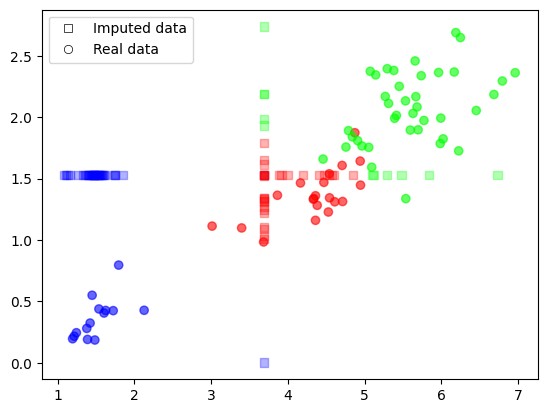

In [7]:
plot_imputation(SimpleImputer(strategy="mean"))

Заполнение на основании алгоритма ближайшего соседа:

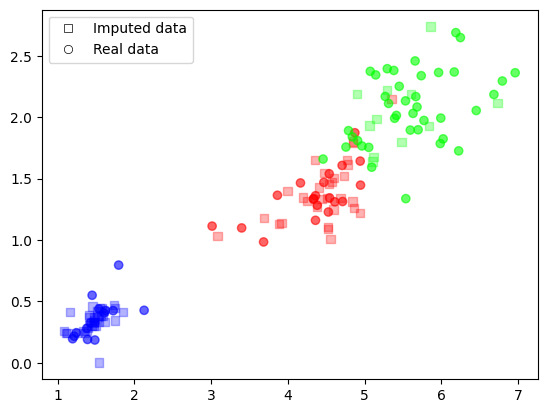

In [8]:
plot_imputation(KNNImputer())

Итеративное заполнение. 

Алгоритм заключается в следующих шагах:

0. Заполнить пропусков константным значением, к примеру $-$ средним.
1. Обучить модель для предсказания пропущенных значений, заполнить пропуски предсказанными значениями.
2. Повторить первый шаг до сходимости или конкретное число шагов.


d:\envs\main\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


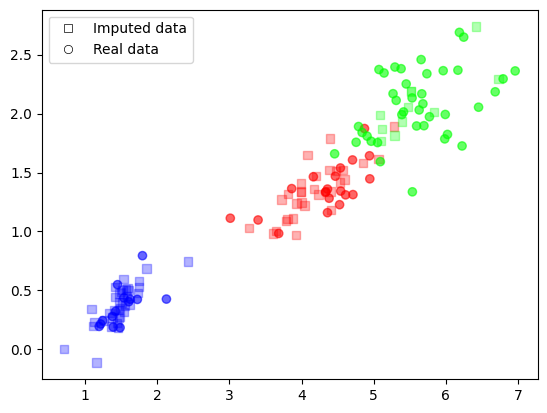

In [9]:
plot_imputation(IterativeImputer(LinearRegression()))

### Заполнение пропусков в нашем наборе данных.

In [10]:
print("Количество пропущенных данных")
df.isna().sum()

Количество пропущенных данных


student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Как видно выше, в нашем наборе данных пропуски только в столбце parental_education_level, поскольку это категориальный признак, заполним пропуски значением моды (самое часто встречаемое значение).

In [11]:
print("Количество значений признака:")
print(df.parental_education_level.value_counts())

Количество значений признака:
parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64


In [12]:
# Заполняем пропуски значением "High School"
df.fillna({"parental_education_level": "High School"}, inplace=True)

## Выделение признаков

Помимо простой обработки признаков также иногда может потребоваться выделить некоторые признаки вручную. Рассмотрим несколько примеров.

Иногда признаки можно формировать на основании других столбцов. К примеру, если есть столбцы даты начала и даты окончания какого-нибудь события, то сами даты скорее всего мало информативны, а вот длительность события окажется намного более полезной. 

Иногда можно включить признак, сформированный совершенно искусственно. Пример: булева переменная является ли день праздничным. Этот признак явно влияет на количество посещений разных мероприятий, если эта информация будет нам полезна

Иногда может быть полезно выделить разные агрегирующие признаки: среднее/минимум/максимум, доля от общего числа. 

Иногда может быть полезно взять данные, вроде суммы значений за последние * дней.

Также может быть полезно выделить разные комбинации признаков. К примеру по имеющимся измерениям вычислить площадь/объём/плотность. Как раз вот тут выражается наше знание о данных, и это знание безусловно надо использовать, это может избавить нас от вычисления полиномиальных признаков.

В целом есть много разных подходов, этому посвящен отдельный раздел наук о данных, называемый <b>Feature Engineering</b>.

В рассматриваемом наборе данных очевидных преобразований подобного рода придумать не удаётся.

In [13]:
df.internet_quality.value_counts()

internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

In [14]:
# Категориальные признаки
categorical_columns = ["gender", "part_time_job", "extracurricular_participation",]
# Ординальные признаки
ordinal_columns =  ["diet_quality", "parental_education_level", "internet_quality"]
# порядок категорий 
ordinals_order = [["Fair", "Good", "Poor"],
                  ["High School", "Bachelor", "Master"],
                  ["Poor", "Average", "Good"]]

# Ординальные признаки в виде чисел
ordinal_columns_numeric =  ["mental_health_rating","exercise_frequency"]
# Цисловые столбцы
numerical_columns = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours", "attendance_percentage", "sleep_hours"]
# балл за экзамен
target_column = "exam_score"

Далее данные необходимо разбить на обучающую и тестовую выборки.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["student_id", "exam_score"])
Y = df["exam_score"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=51, test_size=0.2)

In [16]:
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error, r2_score

models = [("Linear Regression", LinearRegression()),
          ("Lasso", Lasso()),
          ("Ridge", Ridge()),
          ("RANSAC", RANSACRegressor())]

tranformer = ColumnTransformer(transformers=[
    # ("categorical", OneHotEncoder(drop="first"), categorical_columns),
    ("categorical", TargetEncoder(), categorical_columns),
    # ("ordinal", OneHotEncoder(drop="first"), ordinal_columns),
    ("ordinal", TargetEncoder(), ordinal_columns),
    # ("ordinal", OrdinalEncoder(categories=ordinals_order), ordinal_columns),
    ("ordinal_numeric", StandardScaler(), ordinal_columns_numeric),
    ("numeric", StandardScaler(), numerical_columns),
],
remainder="passthrough")# Остальные столбцы не меняются

results =[]
for name, model in models:
    pipe = make_pipeline(tranformer, model)
    pipe.fit(X_train, Y_train)
    rez = {"name":name, 
           "train r2": pipe.score(X_train, Y_train),
           "test r2": pipe.score(X_test, Y_test)}
    results.append(rez)
result_df = pd.DataFrame(results)
result_df.sort_values(by="test r2", ascending=False)

,name,train r2,test r2
2,Ridge,0.901270,0.898862
0,Linear Regression,0.901093,0.898219
3,RANSAC,0.891592,0.887638
1,Lasso,0.876444,0.866382


Text(0, 0.5, 'Ground Thuth')

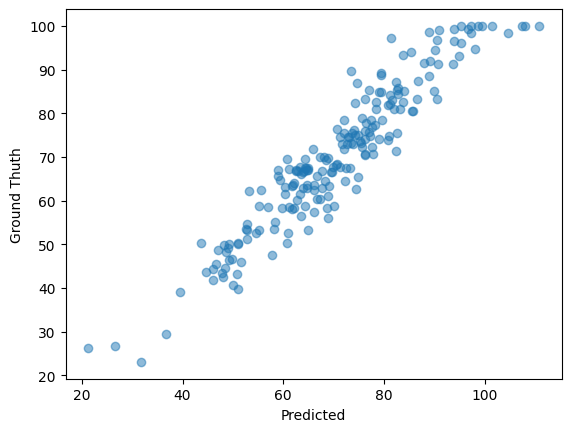

In [17]:
pipe = make_pipeline(tranformer, LinearRegression())
pipe.fit(X_train, Y_train)

Y_predicted = pipe.predict(X_test)

plt.scatter(Y_predicted,Y_test,  alpha=0.5)
plt.xlabel("Predicted")
plt.ylabel("Ground Thuth")
